<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/Pandas_with_AI_on_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Steps to USE **AI** to generate code for your **Dataframe**

**Step1:** Load your dataset

In [2]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/cyber_training_dataset/cyber_crime_logs.csv')

**Step2:** Print First Five rows using `df.head()`

In [3]:
df.head()

,case_id,timestamp,crime_type,location,ip_address,user_id,device_type,amount_lost,status
0,CC0001,2026-03-28 08:41:24,Identity Theft,Mumbai,192.168.44.120,U3992,Mobile,6324,Open
1,CC0002,2026-03-13 08:41:24,Identity Theft,Chandigarh,192.168.19.89,U6310,Mobile,40940,Under Investigation
2,CC0003,2026-03-07 08:41:24,Phishing,Bangalore,192.168.133.236,U4436,Mobile,47465,Closed
3,CC0004,2026-03-07 08:41:24,Identity Theft,Bangalore,192.168.36.157,U5688,Laptop,32529,Under Investigation
4,CC0005,2026-03-09 08:41:24,Identity Theft,Bangalore,192.168.166.163,U2326,Mobile,31716,Open


**Step3:** Click on Generate code with df

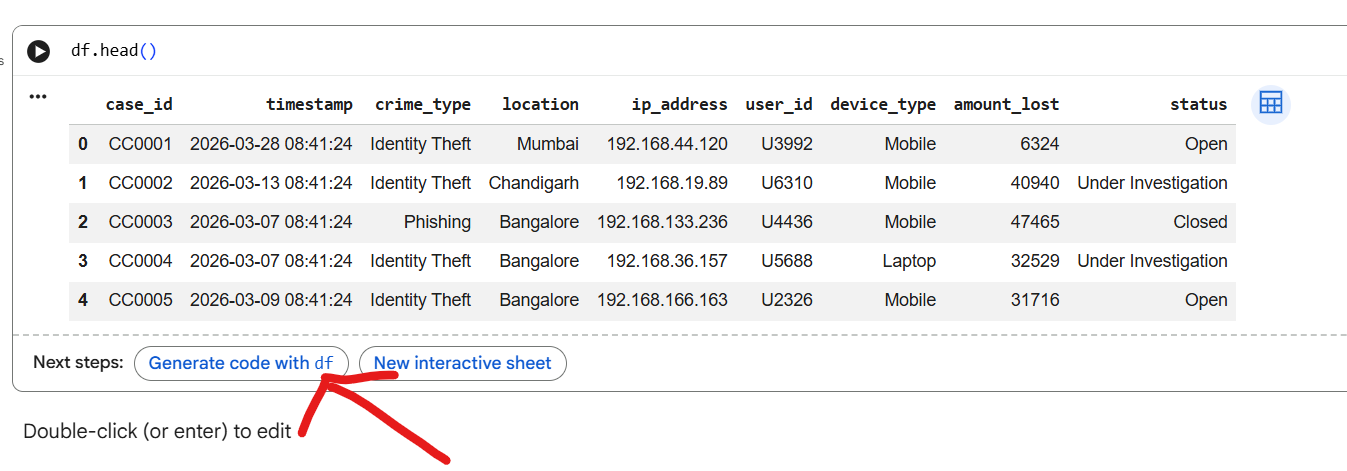

**Step4:** Write good prompt (Just tell AI What you want to achieve)

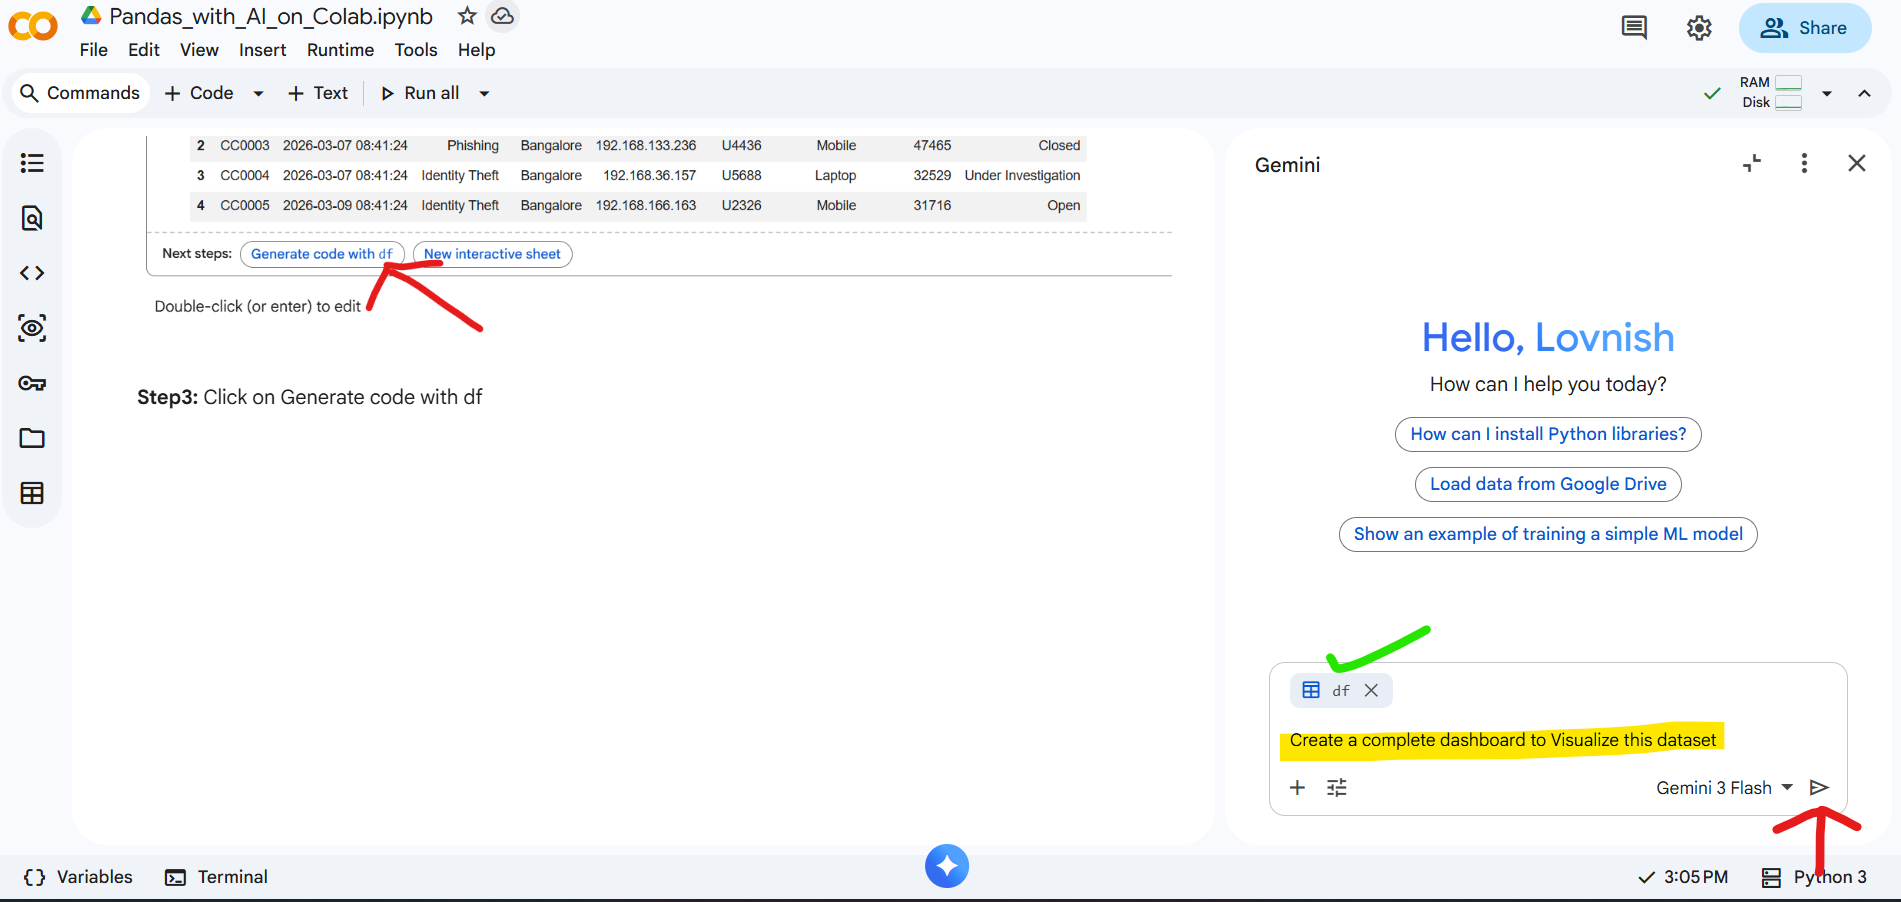

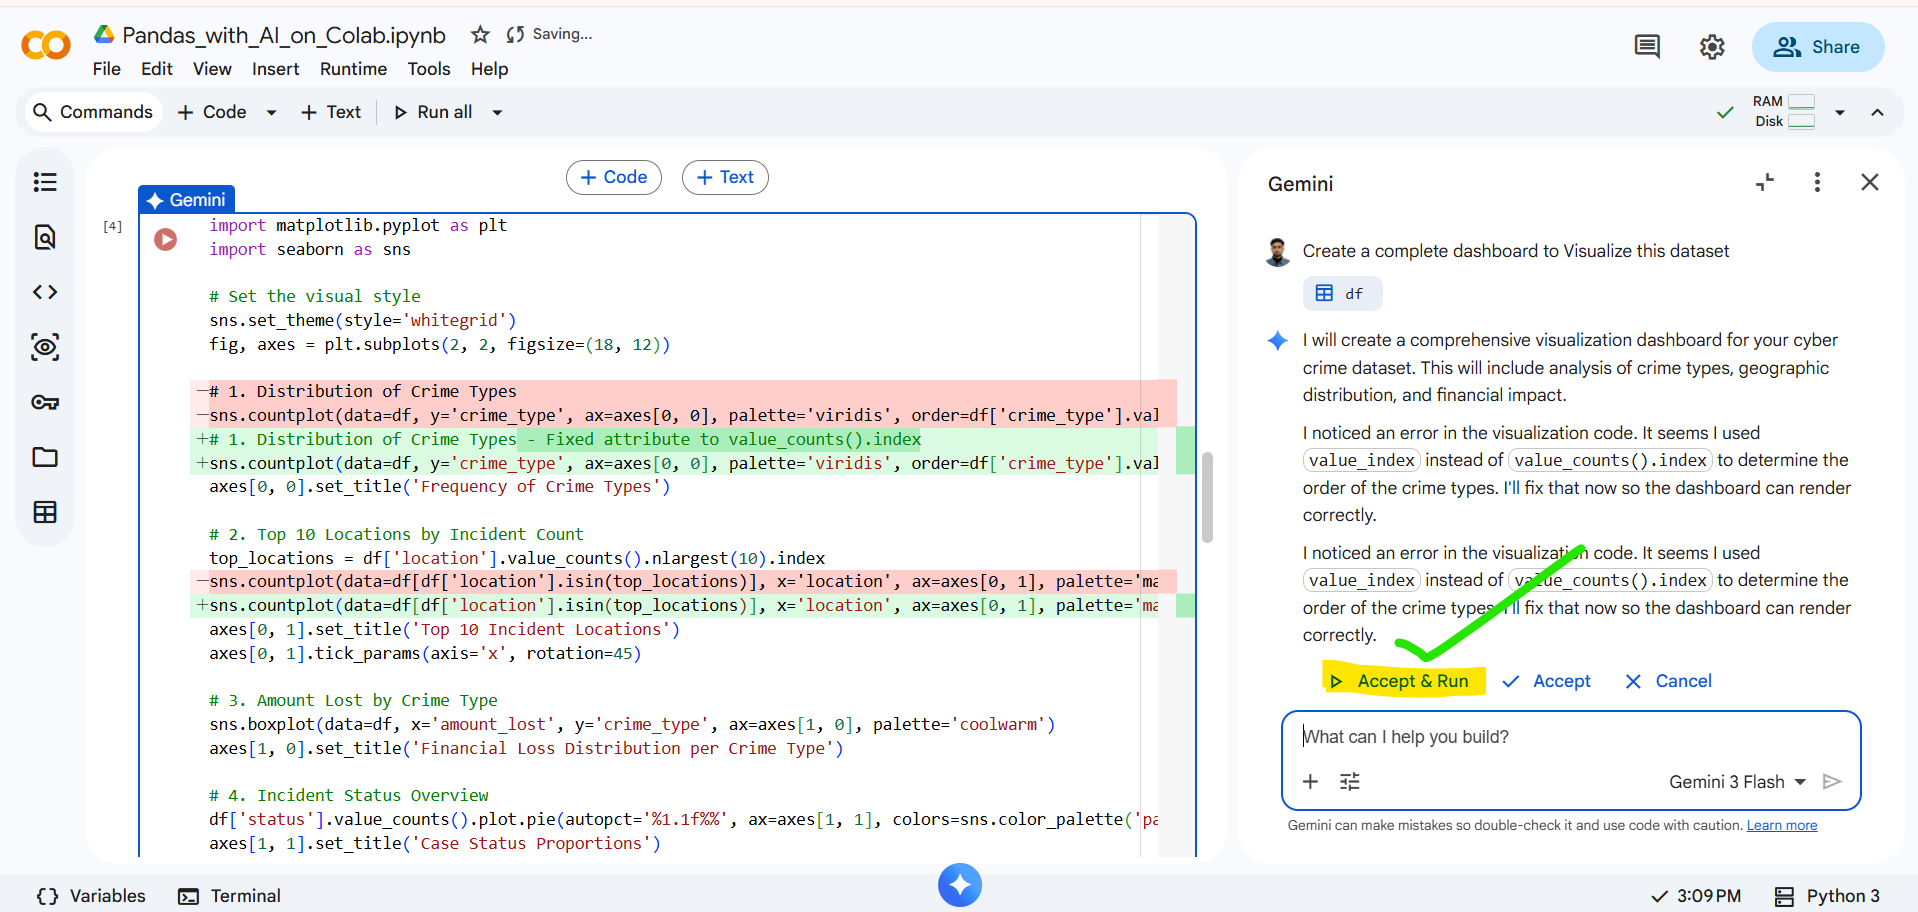



---



*Below Code is generated by AI*

## Cyber Crime Data Visualization Dashboard
In this section, we will analyze the `df` dataframe to uncover patterns in crime types, locations, and financial losses.

/tmp/ipykernel_9252/2855445175.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='crime_type', ax=axes[0, 0], palette='viridis', order=df['crime_type'].value_counts().index)
/tmp/ipykernel_9252/2855445175.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['location'].isin(top_locations)], x='location', ax=axes[0, 1], palette='magma', order=top_locations)
/tmp/ipykernel_9252/2855445175.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='amount_lost', y='crime_type', ax=axes[1, 0], palette='coolwarm')

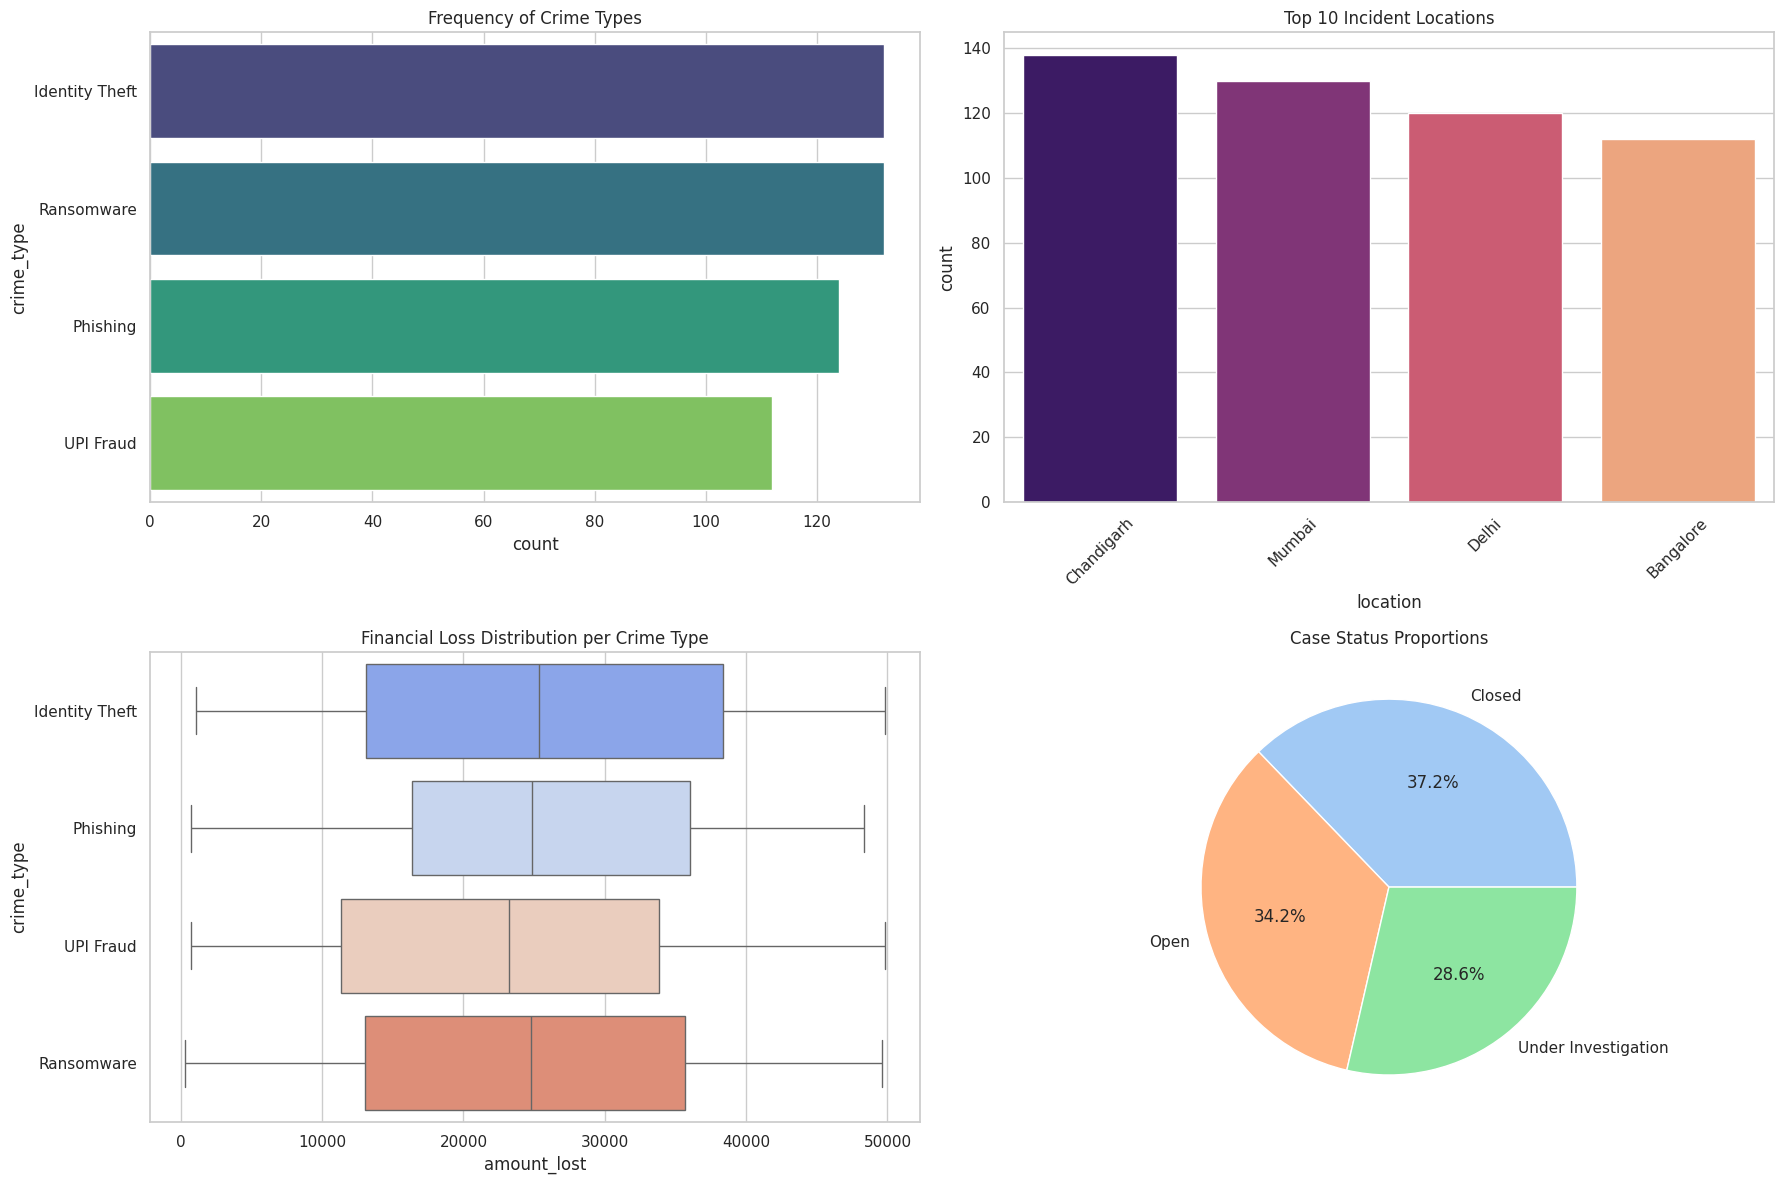

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Distribution of Crime Types - Fixed attribute to value_counts().index
sns.countplot(data=df, y='crime_type', ax=axes[0, 0], palette='viridis', order=df['crime_type'].value_counts().index)
axes[0, 0].set_title('Frequency of Crime Types')

# 2. Top 10 Locations by Incident Count
top_locations = df['location'].value_counts().nlargest(10).index
sns.countplot(data=df[df['location'].isin(top_locations)], x='location', ax=axes[0, 1], palette='magma', order=top_locations)
axes[0, 1].set_title('Top 10 Incident Locations')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Amount Lost by Crime Type
sns.boxplot(data=df, x='amount_lost', y='crime_type', ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Financial Loss Distribution per Crime Type')

# 4. Incident Status Overview
df['status'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1, 1], colors=sns.color_palette('pastel'))
axes[1, 1].set_title('Case Status Proportions')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

In [5]:
# Summary Statistics for numerical insights
summary_stats = df.groupby('crime_type')['amount_lost'].agg(['count', 'mean', 'sum']).sort_values(by='sum', ascending=False)
print("Summary of Financial Loss by Crime Type:")
display(summary_stats)

Summary of Financial Loss by Crime Type:


,count,mean,sum
crime_type,,,
Identity Theft,132,25451.598485,3359611
Ransomware,132,24341.136364,3213030
Phishing,124,25283.935484,3135208
UPI Fraud,112,23753.062500,2660343


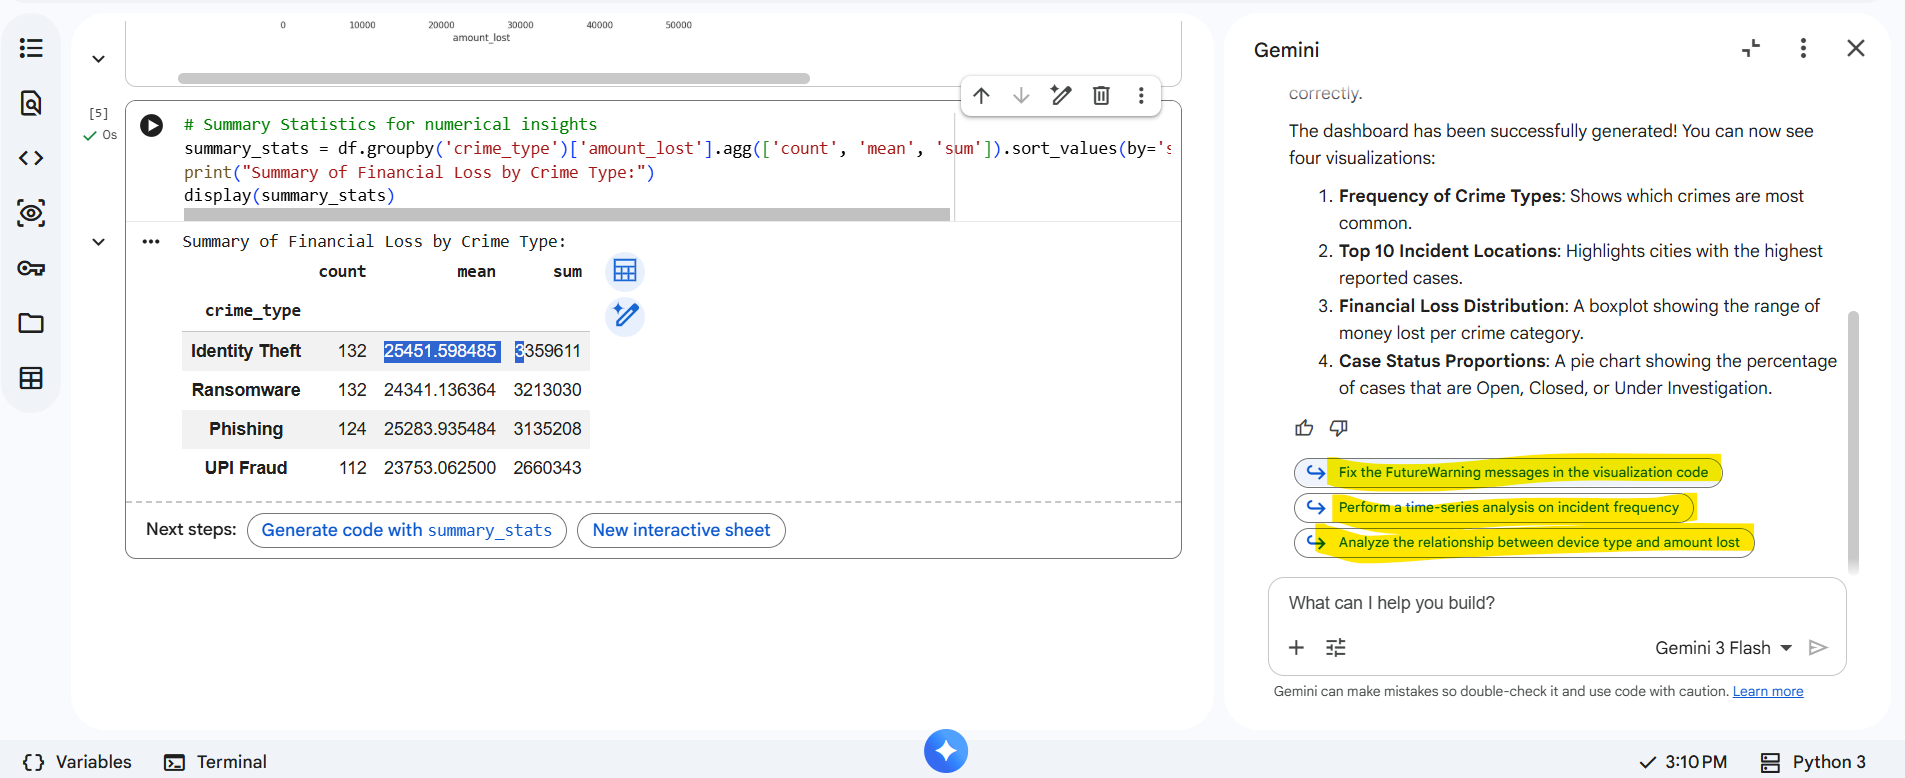

In [7]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Prepare data for dashboard using the 'df' variable
crime_counts = df['crime_type'].value_counts().reset_index()
loc_counts = df['location'].value_counts().reset_index()

# Create a multi-plot dashboard
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'type': 'domain'}, {'type': 'xy'}],
           [{'type': 'xy', 'colspan': 2}, None]],
    subplot_titles=('Crime Type Distribution', 'Cases by Location', 'Amount Lost by Crime Type')
)

# 1. Pie Chart - Crime Type
fig.add_trace(go.Pie(labels=crime_counts['crime_type'], values=crime_counts['count'], name='Crimes'), 1, 1)

# 2. Bar Chart - Locations
fig.add_trace(go.Bar(x=loc_counts['location'], y=loc_counts['count'], name='Locations', marker_color='indianred'), 1, 2)

# 3. Box Plot - Financial Impact
fig.add_trace(go.Box(x=df['crime_type'], y=df['amount_lost'], name='Amount Lost'), 2, 1)

# Update layout for a beautiful look
fig.update_layout(
    height=800,
    title_text='Cyber Crime Analytics Dashboard',
    template='plotly_dark',
    showlegend=False
)

fig.show()

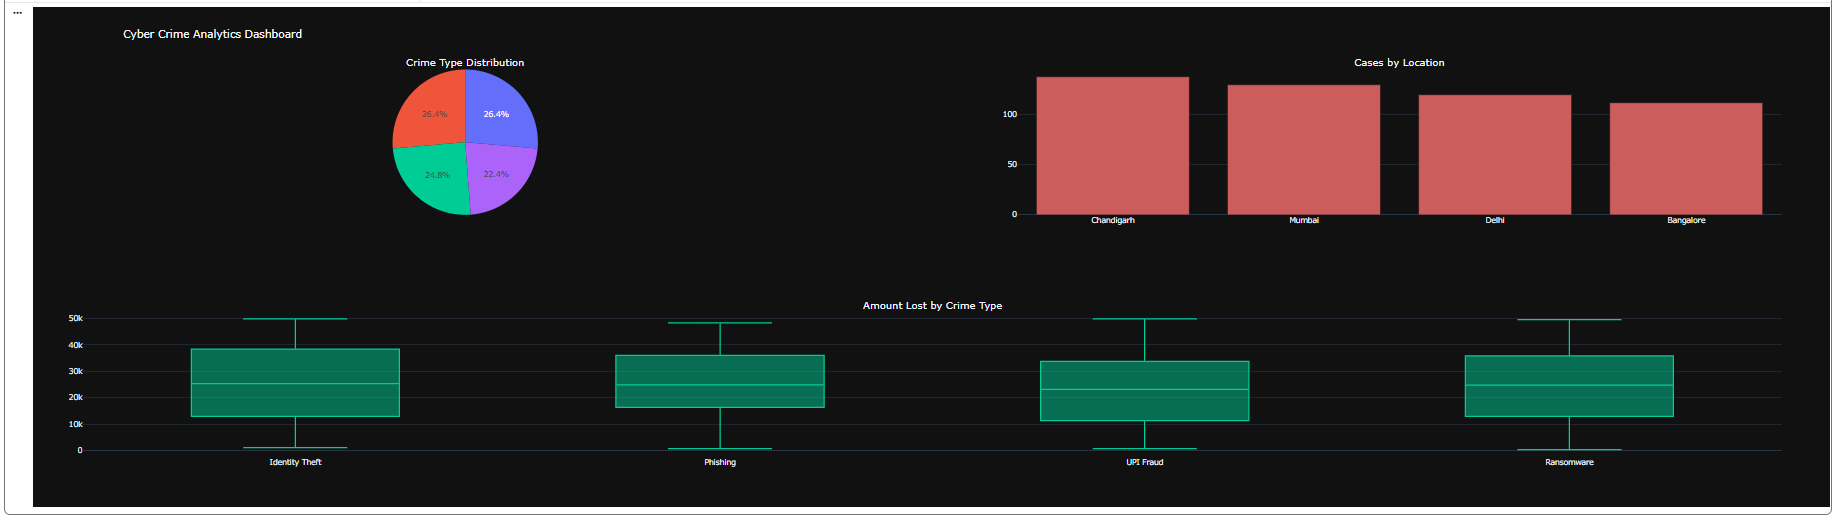



---



*ThankYou*